In [15]:
#importing libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

#loading dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#data cleaanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [16]:
#create a new data fram for usa data(df_us) => 1
df_us = df[df['job_country'] == 'United States'].copy()

In [17]:
#create a new series named job_posted_month => 2
df_us['job_posted_month'] = df_us['job_posted_date'].dt.strftime('%B')

In [18]:
#creat a pivot_table for plot =>3
df_us_pivot = df_us.pivot_table(index='job_posted_month', columns='job_title_short', aggfunc='size')

In [19]:
#reset index of data (new index => zero indexing) => 4
df_us_pivot.reset_index(inplace=True)
#create a new serise called 'month_num' include number of months
df_us_pivot['month_num'] = pd.to_datetime(df_us_pivot['job_posted_month'], format= '%B').dt.month
#sort months numbers from smaller to bigger => 5
df_us_pivot.sort_values('month_num', inplace=True)
#set job_posted_month as a index to data fram after sort month number => 6
df_us_pivot.set_index('job_posted_month', inplace=True)
#drop month num => 7
df_us_pivot.drop(columns='month_num', inplace=True)
df_us_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114
February,447,24,6124,3060,4956,56,1258,878,1127,90
March,438,19,6218,3183,4779,59,1114,829,1150,115
April,565,40,6049,2801,4867,51,1025,781,991,112
May,279,20,4993,2976,4377,49,839,746,914,90
June,446,32,5683,2893,4645,48,1009,812,1033,93
July,581,39,5201,2570,4876,65,883,747,1095,153
August,903,39,6634,3269,6318,68,1186,903,1515,194
September,897,50,4639,3224,4568,113,805,775,1014,228


<Axes: xlabel='job_posted_month'>

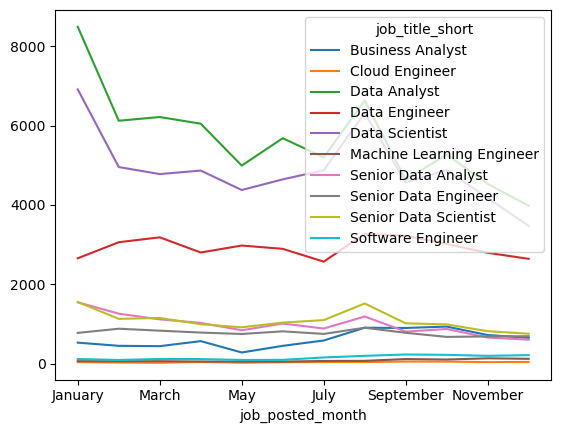

In [20]:
df_us_pivot.plot(kind= 'line')

In [21]:
top_3 = df_us['job_title_short'].value_counts().head(3)
top_3 = top_3.index.tolist()

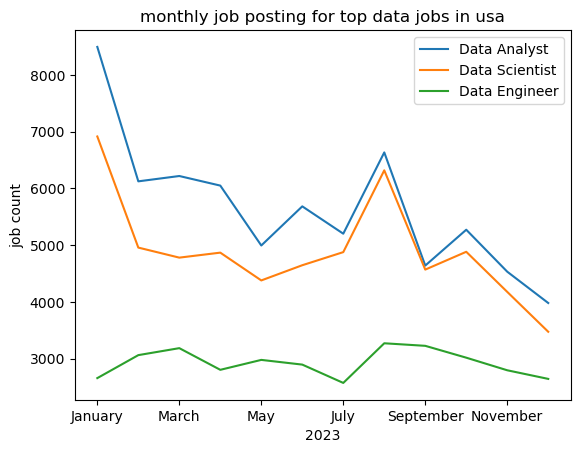

In [26]:
df_us_pivot[top_3].plot(kind= 'line')
plt.title('monthly job posting for top data jobs in usa')
plt.xlabel('2023')
plt.ylabel('job count')
plt.legend()
plt.show()